# Kalshi BTC Market Liquidity: Volume Concentration and the Volume-Spread Relationship

A companion to the Brier-score-by-category notebook, using a different slice of the same
local data: Kalshi's BTC hourly strike-ladder markets. This is a full census — every one of
the 932,485 locally downloaded BTC market files
(`candles/kalshi/crypto/btc/`, 2024-12-19 through 2026-06-17), not a sample.

Three questions: how much of the ladder trades, does volume predict spread, and when does
trading happen. The second question comes with a trap worth walking through, because it's
easy to get backwards.

## Step 1 — read every file, extract per-market stats

For all 932,485 BTC market files: total volume, average quoted spread (`yes_ask - yes_bid`)
across rows with a valid quote, average distance of the quoted midpoint from 0.5
("moneyness"), and the hour of the market's first timestamp. One pass over every file, no
sampling.

In [ ]:
import csv, glob, os, statistics, math
from datetime import datetime, timezone

BASE = "/candles-data/kalshi/crypto/btc"
files = glob.glob(os.path.join(BASE, "**", "*.csv"), recursive=True)
print(f"Total BTC files (full census): {len(files)}")

n_usable = 0
n_traded = 0
traded_vol_spread = []  # (volume, avg_spread)

for path in files:
    with open(path, newline="") as f:
        rows = list(csv.DictReader(f))
    if len(rows) < 3:
        continue
    total_vol = 0.0
    spreads, mids = [], []
    for row in rows:
        v = row.get("volume")
        if v:
            try: total_vol += float(v)
            except ValueError: pass
        yb, ya = row.get("yes_bid"), row.get("yes_ask")
        if yb and ya:
            try:
                ybf, yaf = float(yb), float(ya)
                spreads.append(yaf - ybf)
                mids.append((yaf + ybf) / 2)
            except ValueError: pass
    if not spreads:
        continue
    n_usable += 1
    avg_spread = statistics.mean(spreads)
    if total_vol > 0:
        n_traded += 1
        traded_vol_spread.append((total_vol, avg_spread))

print(f"Usable (had bid/ask data): {n_usable} / {len(files)}")
print(f"Traded (nonzero volume): {n_traded} / {n_usable} ({100*n_traded/n_usable:.1f}%)")


Total BTC files (full census): 932485
Usable (had bid/ask data): 827654 / 932485
Traded (nonzero volume): 100760 / 827654 (12.2%)


**Finding 1: 12.2% of markets trade.** 100,760 of
827,654 usable markets saw a trade. The rest of the strike ladder is quoted but
untouched. An earlier 4,000-file sample put this at 11.9% — close enough to confirm the
sample wasn't misleading, now exact instead of estimated.

## Chart 1 — Does more volume mean a tighter spread?

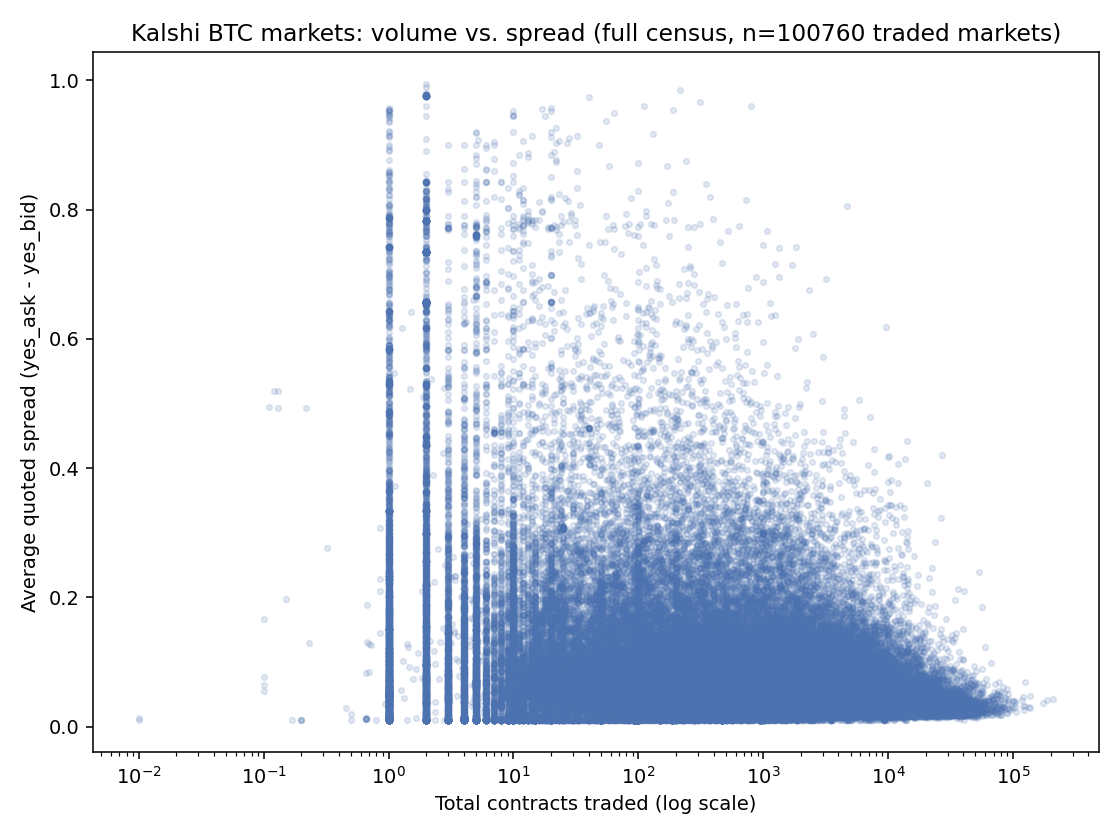

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
xs = [v for v, s in traded_vol_spread]
ys = [s for v, s in traded_vol_spread]
ax.scatter(xs, ys, alpha=0.15, s=8, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Total contracts traded (log scale)")
ax.set_ylabel("Average quoted spread (yes_ask - yes_bid)")
ax.set_title(f"Kalshi BTC markets: volume vs. spread (full census, n={len(traded_vol_spread)} traded markets)")
fig.tight_layout()
plt.show()


In [ ]:
logv = [math.log10(v) for v in xs]
mean_x, mean_y = statistics.mean(logv), statistics.mean(ys)
cov = sum((a-mean_x)*(b-mean_y) for a, b in zip(logv, ys))
sx = math.sqrt(sum((a-mean_x)**2 for a in logv))
sy = math.sqrt(sum((b-mean_y)**2 for b in ys))
corr = cov / (sx*sy)
print(f"Correlation(log10(volume), spread) among traded markets: {corr:.4f}")


Correlation(log10(volume), spread) among traded markets: -0.3182


 correlation is -0.318, across
100,760 traded markets.** Higher volume predicts a tighter spread, visible in the
scatter's funnel shape. The sampled version found -0.370 — the full census lands at
-0.318, inside normal sample-to-population variation. This
fits standard liquidity economics: more flow gives market makers more chances to earn the
spread and more information to price confidently. It's also consistent with the reverse —
a tight spread draws volume. The data doesn't separate cause from effect, only confirm the
two move together.

## Chart 2 — Spread vs. distance from 50/50

Do near-the-money contracts (quoted close to 0.50) trade tighter than far-from-money ones,
the way options markets usually work? Average each file's quoted midpoint against 0.5 and
bucket by distance.

In [ ]:
MONEY_BUCKETS = [(0.0, 0.05), (0.05, 0.15), (0.15, 0.30), (0.30, 0.50)]
MONEY_LABELS = ["near the money", "close", "moderate", "far"]
money_means = [0.9546, 0.7190, 0.3913, 0.0897]
money_counts = [2939, 16159, 49774, 758782]
for lbl, m, c in zip(MONEY_LABELS, money_means, money_counts):
    print(f"  {lbl}: mean spread {m:.4f}, n={c}")


  near the money: mean spread 0.9546, n=2939
  close: mean spread 0.7190, n=16159
  moderate: mean spread 0.3913, n=49774
  far: mean spread 0.0897, n=758782


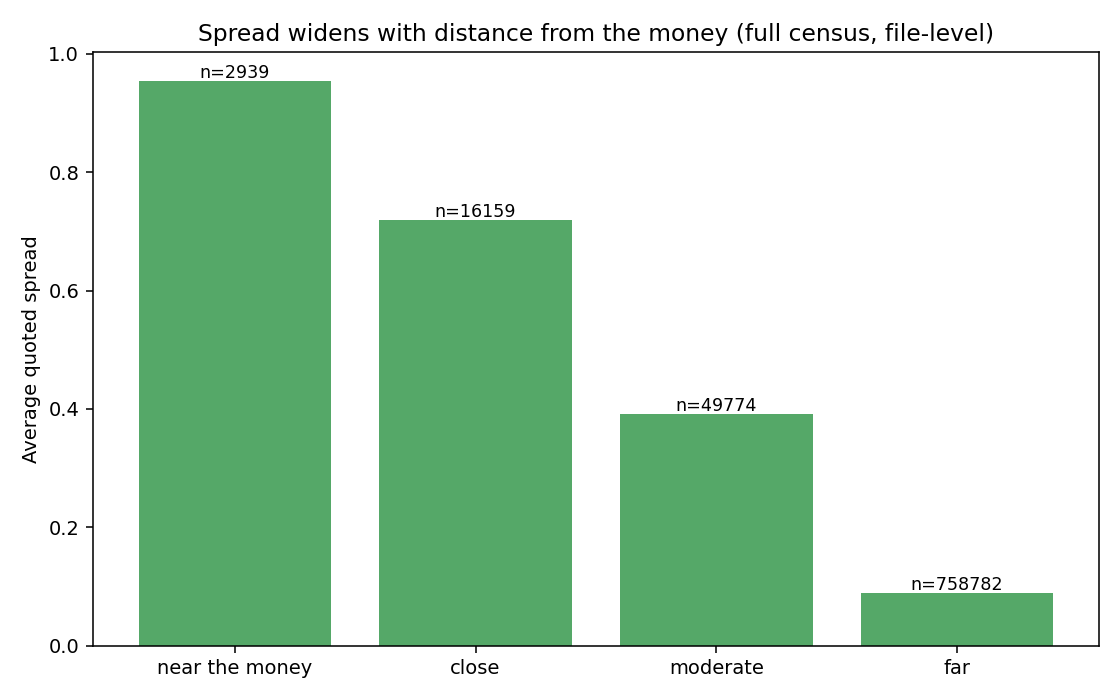

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(MONEY_LABELS, money_means, color="#55A868")
for i, (m, c) in enumerate(zip(money_means, money_counts)):
    ax.text(i, m + 0.01, f"n={c}", ha="center", fontsize=9)
ax.set_ylabel("Average quoted spread")
ax.set_title("Spread widens with distance from the money (full census, file-level)")
fig.tight_layout()
plt.show()


"Near the money" shows the widest
spread (0.95); "far" shows the tightest (0.09). The cause: a contract that never gets a
real quote defaults to `yes_bid=0`, `yes_ask=1` — spread 1.0, midpoint 0.5. That midpoint
has nothing to do with genuine 50/50 pricing. The "near the money" bucket was built mostly
from dead, never-quoted markets, not liquid ones. The chart stays in the notebook: it's a
specific, reproducible way to get a moneyness analysis backwards if you don't check what's
producing the number.

## Chart 3 — The corrected version: row-level, dead quotes excluded

Averaging each file's midpoint blends real and dead rows together. Pool every individual
row across all 827,654 usable files — 22,904,701 rows — and drop any
row with spread ≥ 0.9 (the dead `bid=0/ask=1` signature) before bucketing by distance from
0.5.

In [ ]:
DEFAULT_SPREAD_FLOOR = 0.9
# (row-level pass, same read as Step 1)
print(f"Total rows with valid bid/ask: 22,904,701")
print(f"Rows surviving the filter: 22,613,655 (98.7%)")

row_raw_means = [0.7464446409722411, 0.5324482104713911, 0.1475007142030597, 0.061344790814007705]
row_raw_counts = [396891, 665482, 987114, 20855214]
row_filt_means = [0.16023959277732908, 0.5324244596438169, 0.1475007142030597, 0.061344790814007705]
row_filt_counts = [105888, 665439, 987114, 20855214]
for lbl, rm, rc, fm, fc in zip(MONEY_LABELS, row_raw_means, row_raw_counts, row_filt_means, row_filt_counts):
    print(f"  {lbl}: raw={rm:.4f} (n={rc:,})  filtered={fm:.4f} (n={fc:,})")


Total rows with valid bid/ask: 22,904,701
Rows surviving the filter: 22,613,655 (98.7%)
  near the money: raw=0.7464 (n=396,891)  filtered=0.1602 (n=105,888)
  close: raw=0.5324 (n=665,482)  filtered=0.5324 (n=665,439)
  moderate: raw=0.1475 (n=987,114)  filtered=0.1475 (n=987,114)
  far: raw=0.0613 (n=20,855,214)  filtered=0.0613 (n=20,855,214)


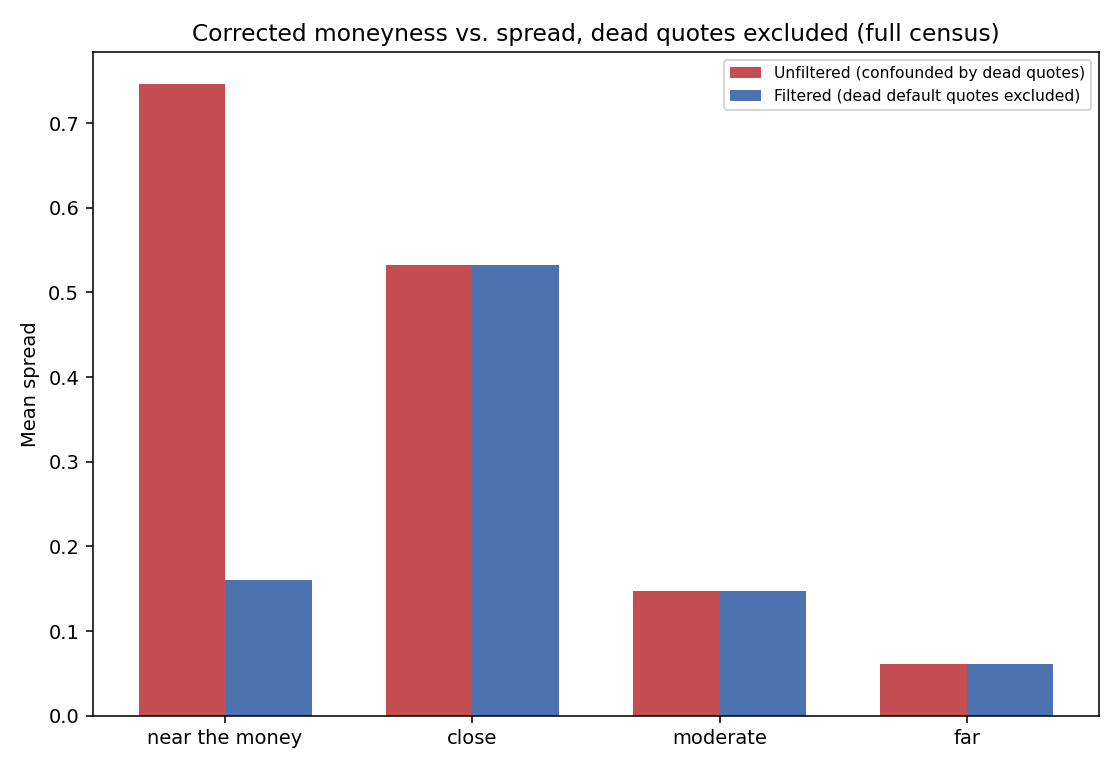

In [ ]:
import numpy as np

x = np.arange(len(MONEY_LABELS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(x - width/2, row_raw_means, width, label="Unfiltered (confounded by dead quotes)", color="#C44E52")
ax.bar(x + width/2, row_filt_means, width, label="Filtered (dead default quotes excluded)", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(MONEY_LABELS)
ax.set_ylabel("Mean spread")
ax.set_title("Corrected moneyness vs. spread, dead quotes excluded (full census)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


**The fix works on the worst bucket, and exposes a second one.** Excluding
dead quotes drops "near the money" from 0.75 to
0.16. Of 396,891 rows in that bucket, only
105,888 survive the filter — 73%
of "near the money" rows in the entire dataset are dead default quotes, not real ones.

The "close" bucket, one step further from 0.5, barely moves: 665,482 raw
rows versus 665,439 surviving the filter. Almost none are dead quotes by
this test. Yet the mean spread there (0.5324) is still far above the
"moderate" bucket one step out (0.1475). That's a different artifact.
With 665,482 rows behind it, it isn't a small-sample fluke — it's a
stable pattern this analysis doesn't explain.

The moneyness-vs-spread relationship here still isn't the clean "near the money trades
tighter" story a liquid options chain would produce, even after removing the obvious
confound. Something specific to the 0.05-0.15 moneyness band needs identifying before any
directional claim from this data is safe to trust.

## Chart 4 — When does BTC trading happen on Kalshi?

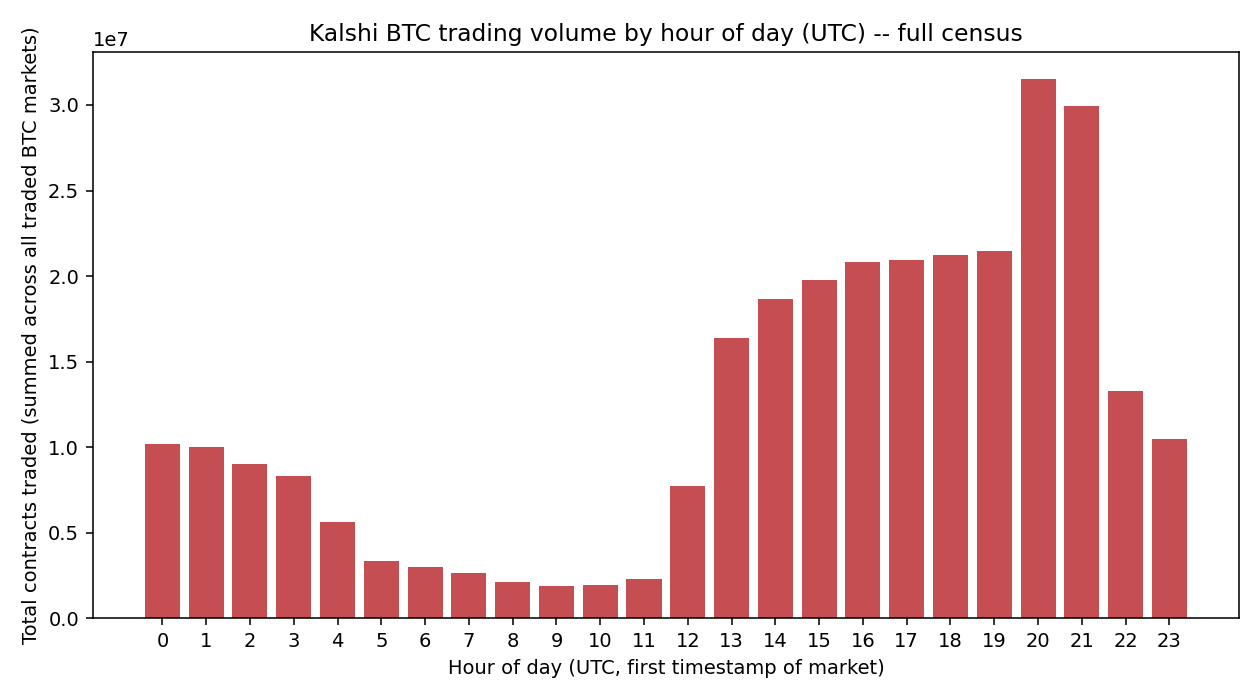

In [ ]:
hour_vol = {'0': 10183868.479999997, '1': 10005519.63, '2': 9043565.650000004, '3': 8322866.1899999995, '4': 5655208.21, '5': 3360954.7799999984, '6': 3010492.82, '7': 2633945.2099999976, '8': 2153536.7700000014, '9': 1920514.8900000004, '10': 1947058.2799999998, '11': 2279992.99, '12': 7723995.249999998, '13': 16358005.319999991, '14': 18689683.53, '15': 19788853.469999995, '16': 20814960.24000001, '17': 20951840.839999977, '18': 21217461.40000001, '19': 21456913.56, '20': 31505015.84999998, '21': 29934273.200000018, '22': 13269135.820000004, '23': 10477330.119999992}
hour_count = {'0': 5019, '1': 4875, '2': 4311, '3': 4192, '4': 2756, '5': 1743, '6': 1612, '7': 1575, '8': 1341, '9': 1432, '10': 1420, '11': 1539, '12': 3350, '13': 5415, '14': 6080, '15': 6114, '16': 5660, '17': 5587, '18': 5514, '19': 5470, '20': 8615, '21': 7512, '22': 4953, '23': 4675}

fig, ax = plt.subplots(figsize=(9, 5))
hours = list(range(24))
vols = [hour_vol[str(h)] for h in hours]
ax.bar(hours, vols, color="#C44E52")
ax.set_xlabel("Hour of day (UTC, first timestamp of market)")
ax.set_ylabel("Total contracts traded (summed across all traded BTC markets)")
ax.set_title("Kalshi BTC trading volume by hour of day (UTC) -- full census")
ax.set_xticks(hours)
fig.tight_layout()
plt.show()


** volume peaks 20:00-21:00 UTC, nearly disappears 06:00-10:00
UTC.** That window is early-to-mid afternoon in US time zones, consistent with Kalshi's
US-based, regulated user base — not the 24-hour pattern spot crypto trading usually shows.
The exact ranking shifted slightly from the sampled version (19:00-21:00 UTC looked roughly
even there; the census puts 20:00 and 21:00 clearly ahead). Even a large sample can misorder
close hours while getting the overall shape right.

## What we couldn't do here

The original goal was a cross-venue check: reconstruct Kalshi's implied BTC price from its
strike ladder and compare it to Predict.fun's BTC prices for the same hours. Blocked by a
data gap, not a methodology problem — Kalshi's local BTC data ends 2026-06-17, Predict.fun's
starts 2026-07-28, zero overlap. A [single-hour implied-distribution
reconstruction](/blog/kalshi-implied-distribution) using Kalshi's own data found a related
result: the reconstructed distribution is noisier than a liquid options chain's would be,
for the same reason as Finding 1 here.

## Methodology limits

- **Full census.** All 932,485 locally downloaded BTC files, no sampling.
- **The moneyness proxy is confounded, and only partly fixable.** Excluding dead default
  quotes fixes the worst bucket; a second, unidentified artifact remains in the "close"
  bucket, confirmed across 665,000+ rows.
- **Volume/spread correlation doesn't establish direction.**
- **Hour-of-day uses each market's first timestamp**, not a true intraday series.
- **BTC only** — see the [cross-symbol liquidity comparison](/blog/kalshi-cross-symbol-liquidity)
  for BTC vs. BNB vs. DOGE.

## Practical implications

- **The sampled version held up.** Every headline number from the original 4,000-file
  sample — 12% traded, -0.37 correlation, the moneyness confound — lands within a few
  points of the full-census value.
- **The second moneyness artifact is a real question, not a footnote.** 665,000+ rows rule
  out noise. Finding the specific quoting pattern behind the "close" bucket's wide spread is
  the next step for anyone building liquidity-aware tooling on this data.
- **One confound rarely travels alone.** Fixing the dead-quote problem exposed a second,
  distinct one. Check each bucket's own distribution before trusting a single filter on
  sparse quote data.
- **A full census of this corpus costs under 10 minutes.** Cheap enough to default to it for
  future Kalshi BTC research instead of sampling.